# Exploratory Data Analysis

Explore the combined KB and the classifier training set.

Input:
- `data/processed/kb_combined.csv` (258,494 records)
- `data/processed/classifier_train.csv` (12,359 records)

Outputs:
- `reports/eda_report.md`
- Figures in `reports/figures/`

In [1]:
import re
from collections import Counter
from datetime import datetime
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent
PROCESSED_DIR = ROOT / "data" / "processed"
REPORTS_DIR = ROOT / "reports"
FIG_DIR = REPORTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
kb = pd.read_csv(PROCESSED_DIR / "kb_combined.csv", low_memory=False)
kb["context"] = kb["context"].fillna("")
kb["answer"] = kb["answer"].fillna("")
kb["category"] = kb["category"].fillna("")

clf_train = pd.read_csv(PROCESSED_DIR / "classifier_train.csv")

print("kb_combined:", kb.shape)
print("classifier_train:", clf_train.shape)
print(kb.columns.tolist())

kb_combined: (258494, 9)
classifier_train: (12359, 2)
['doc_id', 'source', 'source_id', 'category', 'question', 'context', 'answer', 'has_answer', 'has_context']


## 1. KB composition

Four sources contribute to the KB. PubMedQA is the largest by a wide margin.

In [3]:
src_counts = kb["source"].value_counts()
print(src_counts)

source
pubmedqa       211269
medredqa        29801
medquad         16407
medlineplus      1017
Name: count, dtype: int64


C:\Users\Matrix\AppData\Local\Temp\ipykernel_22468\3954945306.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=src_counts.values, y=src_counts.index, ax=axes[0], palette="viridis")


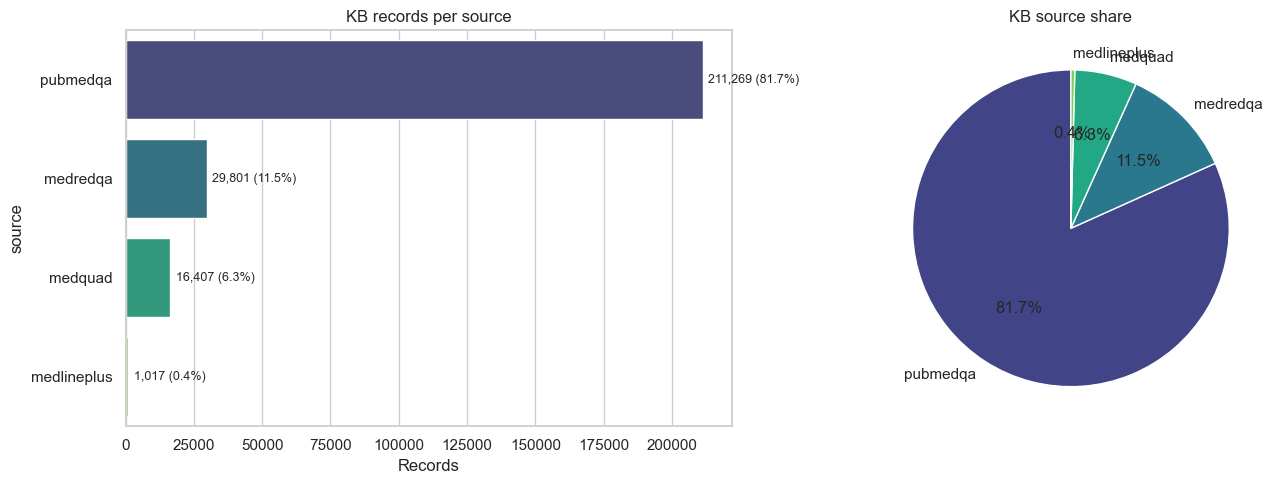

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=src_counts.values, y=src_counts.index, ax=axes[0], palette="viridis")
axes[0].set_title("KB records per source")
axes[0].set_xlabel("Records")
for i, v in enumerate(src_counts.values):
    axes[0].text(v + 2000, i, f"{v:,} ({v/len(kb)*100:.1f}%)", va="center", fontsize=9)

axes[1].pie(
    src_counts.values,
    labels=src_counts.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("viridis", len(src_counts)),
    startangle=90,
)
axes[1].set_title("KB source share")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_source_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Category coverage

Only MedQuAD has real categories (from NIH qtype). The other three sources have an empty category column.

In [5]:
kb["has_category"] = kb["category"].astype(str).str.strip() != ""
kb.groupby("source")["has_category"].agg(["sum", "count", "mean"]).round(3)

,sum,count,mean
source,,,
medlineplus,0,1017,0.0
medquad,16407,16407,1.0
medredqa,0,29801,0.0
pubmedqa,0,211269,0.0


C:\Users\Matrix\AppData\Local\Temp\ipykernel_22468\2200482283.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=medquad_cats.values, y=medquad_cats.index, ax=ax, palette="husl")


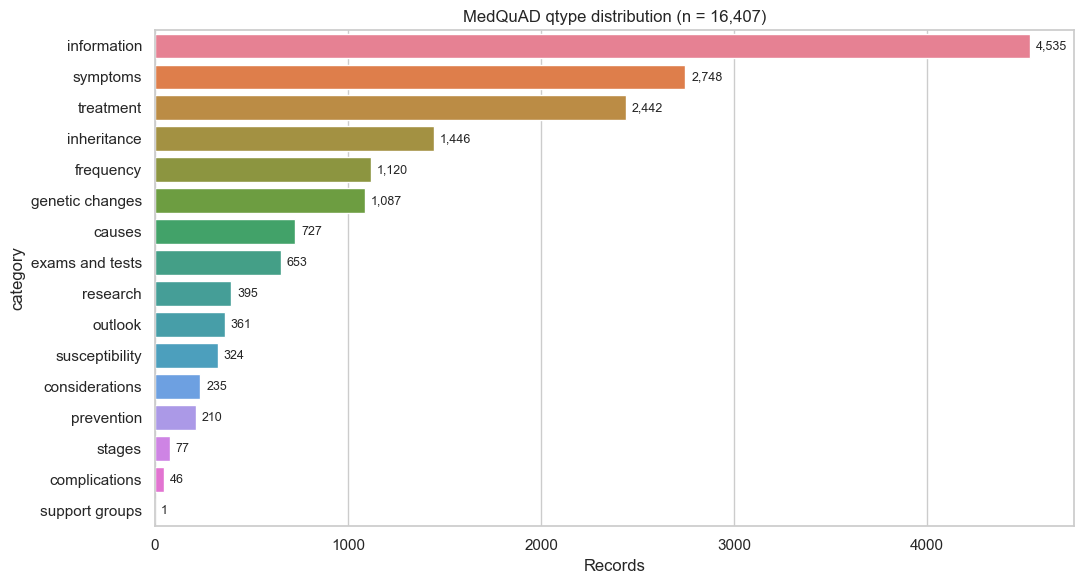

In [6]:
medquad_cats = kb.loc[kb["source"] == "medquad", "category"].value_counts()

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=medquad_cats.values, y=medquad_cats.index, ax=ax, palette="husl")
ax.set_title(f"MedQuAD qtype distribution (n = {medquad_cats.sum():,})")
ax.set_xlabel("Records")
for i, v in enumerate(medquad_cats.values):
    ax.text(v + 30, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_medquad_categories.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Length features

Word counts per field. Used later to decide on chunk size.

In [7]:
for col in ["question", "context", "answer"]:
    kb[f"{col}_len"] = kb[col].astype(str).str.split().str.len()

kb[["question_len", "context_len", "answer_len"]].describe().round(1)

,question_len,context_len,answer_len
count,258494.0,258494.0,258494.0
mean,14.1,185.7,52.5
std,5.0,91.8,83.1
min,1.0,0.0,0.0
25%,11.0,152.0,26.0
50%,14.0,192.0,37.0
75%,17.0,223.0,52.0
max,102.0,4518.0,4281.0


In [8]:
per_src = kb.groupby("source")[["question_len", "context_len", "answer_len"]].median().astype(int)
print(per_src)

             question_len  context_len  answer_len
source                                            
medlineplus             4            0         192
medquad                 7            0         138
medredqa                8          153          47
pubmedqa               15          198          34


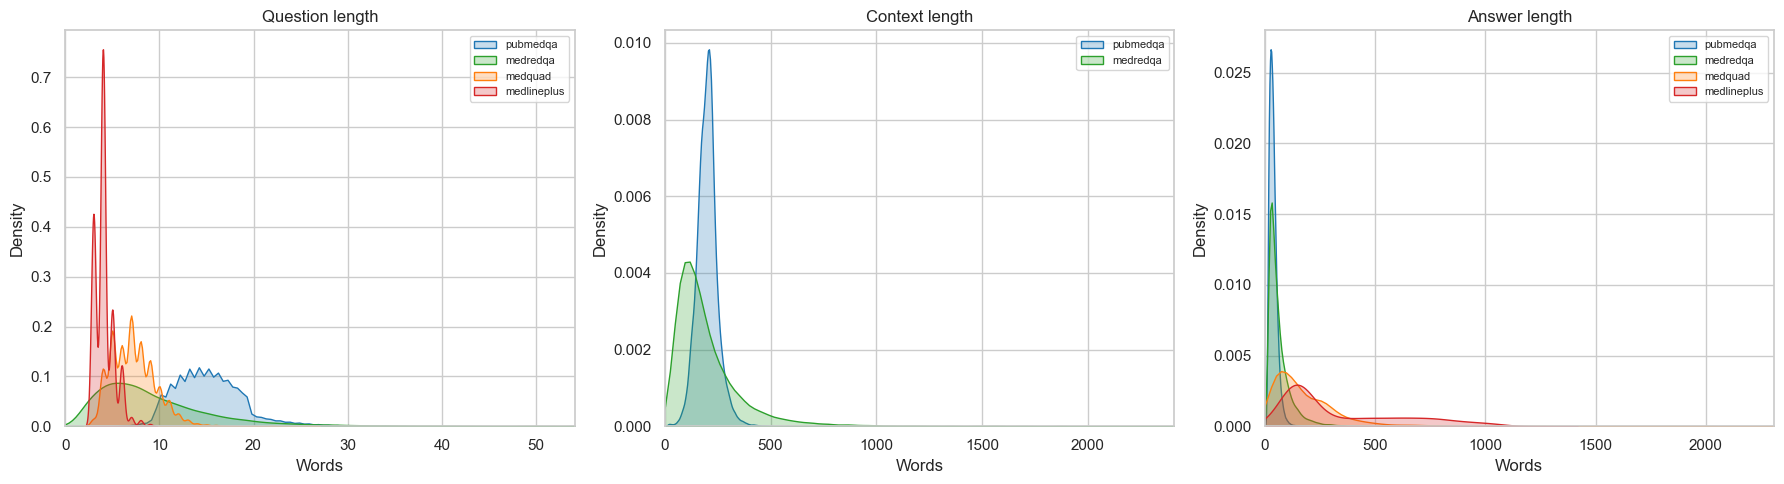

In [9]:
sources = ["pubmedqa", "medredqa", "medquad", "medlineplus"]
colors = {"pubmedqa": "#1f77b4", "medredqa": "#2ca02c", "medquad": "#ff7f0e", "medlineplus": "#d62728"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, label in zip(axes, ["question_len", "context_len", "answer_len"],
                          ["Question", "Context", "Answer"]):
    for src in sources:
        if col == "context_len" and src in ("medquad", "medlineplus"):
            continue
        data = kb.loc[kb["source"] == src, col]
        sns.kdeplot(data=data, ax=ax, label=src, color=colors[src], fill=True, alpha=0.25)
    ax.set_title(f"{label} length")
    ax.set_xlabel("Words")
    ax.set_xlim(0, ax.get_xlim()[1] * 0.5)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "03_length_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

C:\Users\Matrix\AppData\Local\Temp\ipykernel_22468\1247235793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=kb, x="source", y="answer_len", ax=ax, palette="husl")


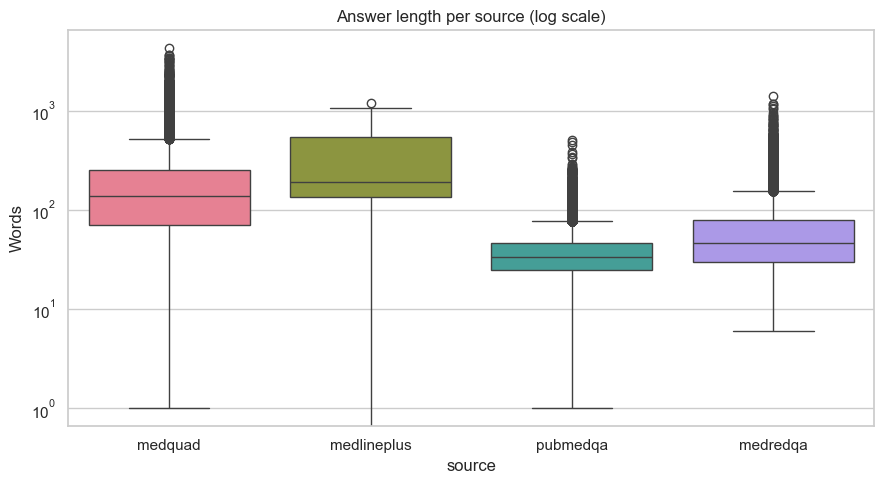

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=kb, x="source", y="answer_len", ax=ax, palette="husl")
ax.set_yscale("log")
ax.set_title("Answer length per source (log scale)")
ax.set_ylabel("Words")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_answer_len_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Top terms per source

PubMedQA dominates 82% of the KB, so a single wordcloud would only show PubMedQA terms. Split per source.

In [11]:
STOP_WORDS = {
    "the", "and", "of", "to", "in", "a", "is", "for", "with", "on", "by", "as",
    "this", "that", "are", "was", "were", "be", "at", "from", "or", "an", "it",
    "not", "but", "have", "has", "had", "which", "we", "you", "they", "their",
    "there", "these", "more", "less", "than", "also", "may", "can", "could",
    "would", "one", "two", "three", "four", "five", "used", "using", "use",
    "results", "result", "shown", "showed", "data", "analysis", "based",
    "however", "although", "while", "since", "after", "before", "during",
    "between", "among", "within", "without", "versus", "compared", "patients",
    "study", "group", "groups", "significant", "significantly", "observed",
    "found", "associated", "total", "mean", "respectively", "number", "performed",
    "received", "reported", "included", "years", "months", "days", "cases",
    "control", "women", "men", "children", "age", "time", "period", "rate",
    "level", "high", "low", "increased", "decreased", "higher", "lower", "similar",
    "difference", "differences", "effect", "effects", "risk", "been", "both",
    "whether", "such", "any", "all", "each", "other", "into", "only", "our",
    "its", "when", "where", "who", "what", "how", "why", "then", "them",
}


def top_terms(texts, n=20):
    words = []
    for t in texts:
        t = re.sub(r"[^a-z\s]", " ", str(t).lower())
        words.extend(w for w in t.split() if w not in STOP_WORDS and len(w) > 3)
    return Counter(words).most_common(n)

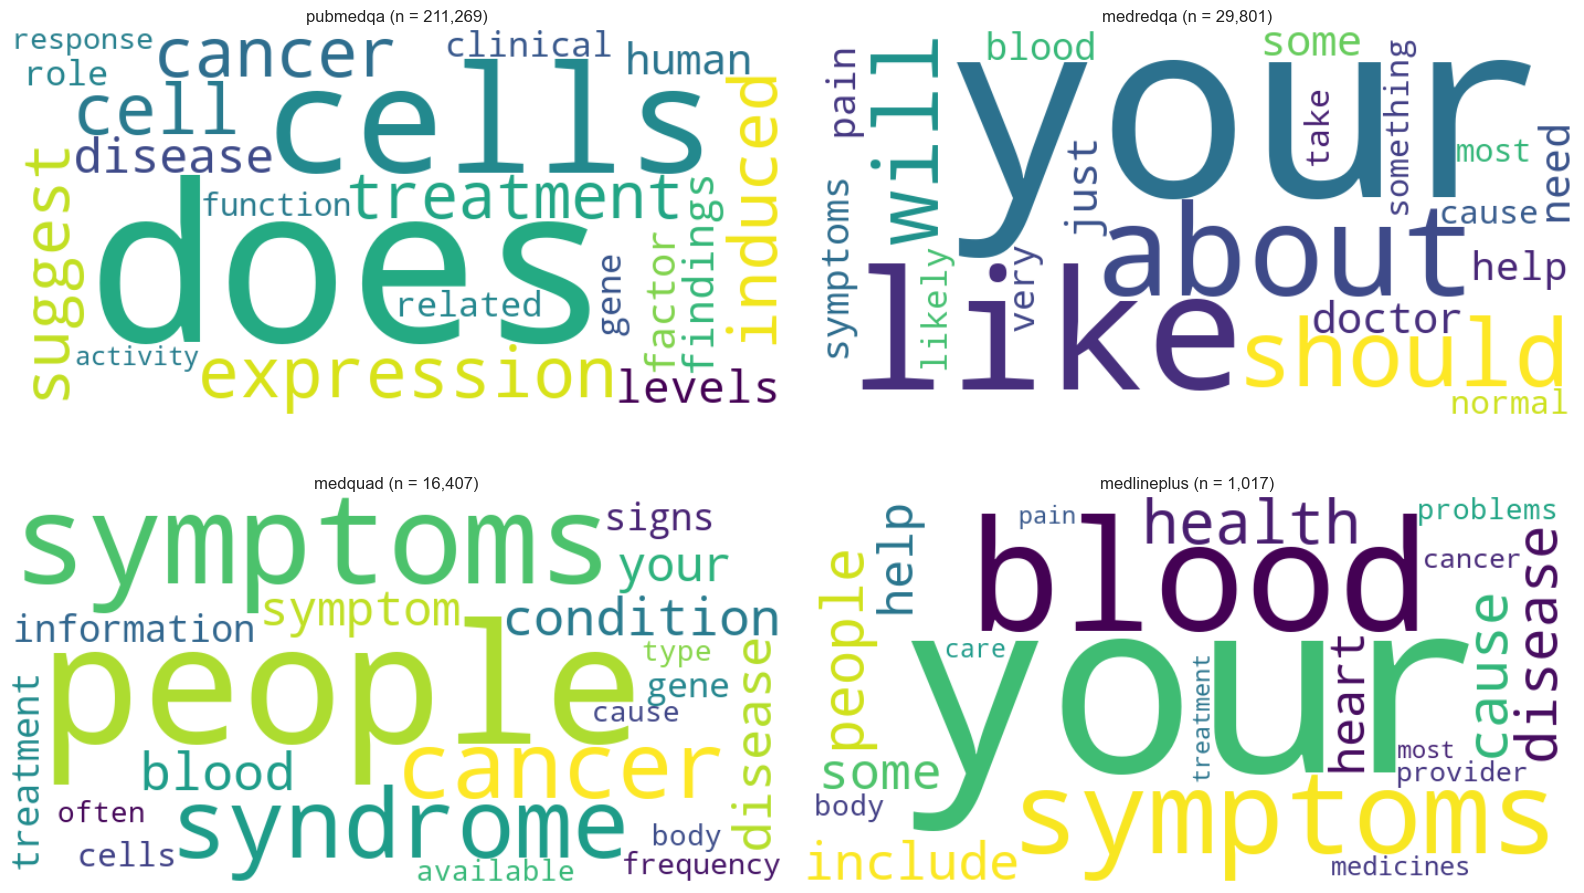

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, src in zip(axes.flat, sources):
    sub = kb[kb["source"] == src]
    text = (sub["question"].astype(str) + " " + sub["answer"].astype(str)).tolist()
    top = top_terms(text, n=20)

    if top:
        wc = WordCloud(
            width=700, height=350,
            background_color="white",
            colormap="viridis",
            max_words=20,
            prefer_horizontal=0.8,
        ).generate_from_frequencies(dict(top))
        ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{src} (n = {len(sub):,})", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "05_top_terms_per_source.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Classifier training set

The mapped MedQuAD labels used for the classifier. Five classes only — MedQuAD has no `Medication` qtype.

In [13]:
label_counts = clf_train["label"].value_counts()
print(label_counts)

imbalance = label_counts.max() / label_counts.min()
print(f"\nImbalance ratio (max/min): {imbalance:.2f}x")

label
General       5905
Symptoms      2748
Treatment     2442
Diagnosis      730
Prevention     534
Name: count, dtype: int64

Imbalance ratio (max/min): 11.06x


C:\Users\Matrix\AppData\Local\Temp\ipykernel_22468\1212687572.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, ax=ax, palette="husl")


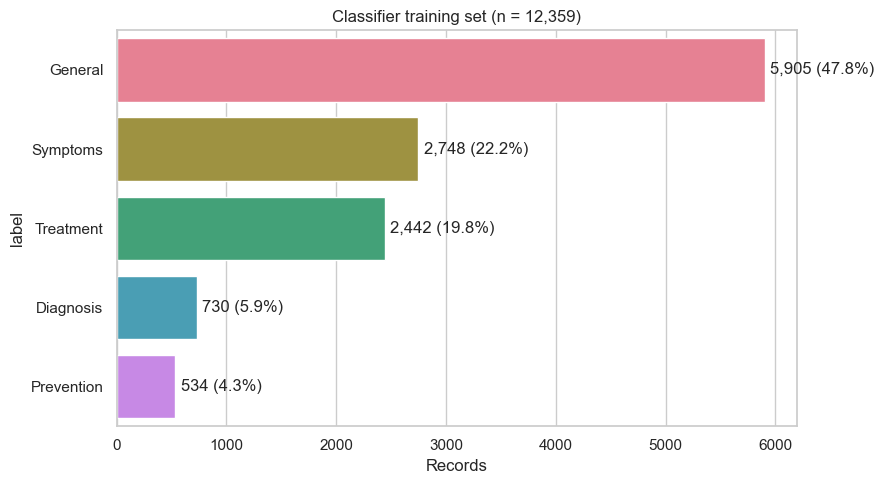

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=label_counts.values, y=label_counts.index, ax=ax, palette="husl")
ax.set_title(f"Classifier training set (n = {len(clf_train):,})")
ax.set_xlabel("Records")
for i, v in enumerate(label_counts.values):
    ax.text(v + 50, i, f"{v:,} ({v/len(clf_train)*100:.1f}%)", va="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_classifier_train_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Length correlation

Only rows with both context and answer are meaningful here — MedQuAD and MedlinePlus have no context.

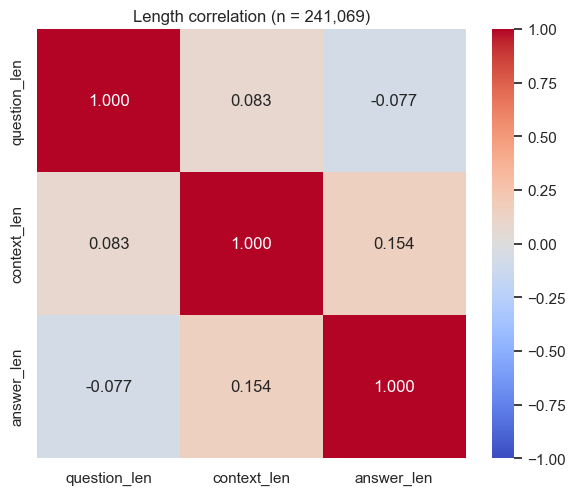

In [15]:
with_ctx = kb[(kb["context_len"] > 0) & (kb["answer_len"] > 0)]
corr = with_ctx[["question_len", "context_len", "answer_len"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", ax=ax, square=True, vmin=-1, vmax=1)
ax.set_title(f"Length correlation (n = {len(with_ctx):,})")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_length_correlation.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Save report

In [16]:
src_rows = "\n".join(
    f"| {s} | {c:,} | {c/len(kb)*100:.2f}% |" for s, c in src_counts.items()
)
cov_rows = "\n".join(
    f"| {s} | {int(r['sum']):,} | {int(r['count']):,} | {r['mean']:.1%} |"
    for s, r in kb.groupby("source")["has_category"].agg(["sum", "count", "mean"]).iterrows()
)
len_rows = "\n".join(
    f"| {s} | {r['question_len']} | {r['context_len']} | {r['answer_len']} |"
    for s, r in per_src.iterrows()
)
clf_rows = "\n".join(
    f"| {l} | {c:,} | {c/len(clf_train)*100:.2f}% |" for l, c in label_counts.items()
)

report = f"""# EDA Report
**Healthcare RAG-Powered Medical Q&A Assistant**
**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

---

## 1. KB composition (n = {len(kb):,})

| Source | Records | Share |
|--------|---------|-------|
{src_rows}

PubMedQA holds 81.7% of the KB, so any aggregate statistic is effectively a PubMedQA statistic. Terms and lengths are reported per source.

## 2. Category coverage

| Source | With category | Total | Coverage |
|--------|---------------|-------|----------|
{cov_rows}

Only MedQuAD carries real labels. The classifier is trained on MedQuAD alone.

## 3. Length statistics (median words)

| Source | Question | Context | Answer |
|--------|----------|---------|--------|
{len_rows}

PubMedQA and MedRedQA carry long contexts (153-198 words). MedQuAD and MedlinePlus have no context — the answer is the full unit.

## 4. Classifier training set (n = {len(clf_train):,})

| Label | Count | Share |
|-------|-------|-------|
{clf_rows}

Imbalance ratio: {imbalance:.2f}x. Class weights should be applied during training.

## 5. Length correlation

| Pair | Correlation |
|------|-------------|
| question ↔ answer | {corr.loc['question_len', 'answer_len']:.3f} |
| context ↔ answer  | {corr.loc['context_len', 'answer_len']:.3f} |
| question ↔ context| {corr.loc['question_len', 'context_len']:.3f} |

No strong correlation. Length cannot leak label information.

## 6. Decisions from this EDA

| Decision | Evidence |
|----------|----------|
| Chunk size 700 / overlap 150 | Median context is ~198 words; splitting by sentence boundaries keeps abstracts intact |
| Train classifier on MedQuAD only | Only source with real labels (12,359 mapped rows) |
| Class-balance the classifier | {imbalance:.1f}x imbalance between largest and smallest class |
| Report terms per source | Global wordcloud would show only PubMedQA vocabulary |

## 7. Figures

1. `01_source_distribution.png`
2. `02_medquad_categories.png`
3. `03_length_distributions.png`
4. `04_answer_len_boxplot.png`
5. `05_top_terms_per_source.png`
6. `06_classifier_train_distribution.png`
7. `07_length_correlation.png`
"""

(REPORTS_DIR / "eda_report.md").write_text(report, encoding="utf-8")
print("report saved:", REPORTS_DIR / "eda_report.md")

report saved: d:\Projects\Healthcare-RAG-Assistant\reports\eda_report.md


Next: `05_embeddings_vectorstore.ipynb`